# Fine-Tune on Buildings 900K

The TTM way first (each time serie cut into train/val/test), with a domain-shit eval way second

In [1]:
import tempfile
import math
import os
import pandas as pd

from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK

from tsfm_public import TimeSeriesPreprocessor, TrackingCallback, count_parameters, get_datasets
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions

import datasets
import numpy as np

from gluonts.model.forecast import SampleForecast
from gluonts.model.evaluation import evaluate_forecasts
from gluonts.ev.metrics import MASE, MeanWeightedSumQuantileLoss
from gluonts.dataset.split import split

/home/joffreyma/miniforge3/envs/chronos_env/lib/python3.11/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [2]:
import warnings


# Suppress all warnings
warnings.filterwarnings("ignore")

In [3]:
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
# Set seed for reproducibility
SEED = 41
set_seed(SEED)

# Results dir
OUT_DIR = "ttm_finetuned_models/"
dataset_name = "buildings_900K"

context_length=512
forecast_length=64
train_batch_size=64
eval_batch_size=1024

pd_batch_size = 3 # 5000

# Dataset
timestamp_column = "timestamp"
id_columns = ["item_id"]  # mention the ids that uniquely identify a time-series.

target_columns = ["target"]
split_config = {
    "train": [
        0,
        4000,# 8761-forecast_length-100,
    ],
    "valid": [
        4000,# 8761-forecast_length-100,
        8761-forecast_length,
    ],
    "test": [
        8761-forecast_length, # the context length is included by the splitter
        8761,
    ],
}
# Understanding the split config -- slides

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}


In [4]:
files = ["../../../chronos-forecasting/data/buildings_900K_chronos_split_ttm/domain_shift/data-00000-of-00001.arrow"]
ds = datasets.load_dataset(
    "arrow", data_files={'train': files}, split="train"
)

In [5]:
data = ds.to_pandas(batch_size=pd_batch_size, batched=True)
data

<generator object Dataset.to_pandas.<locals>.<genexpr> at 0x7905d22609d0>

# Fine-tuning code

In [6]:
dataset_name=dataset_name
context_length=context_length
forecast_length=forecast_length
fewshot_percent=1
learning_rate=0.001
freeze_backbone=True
num_epochs=5
save_dir=OUT_DIR
loss="mse"
quantile=0.5

In [7]:
out_dir = os.path.join(save_dir, dataset_name)

print("-" * 20, f"Running few-shot {fewshot_percent}%", "-" * 20)

# Data prep: Get dataset

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)

# change head dropout to 0.7 for ett datasets
finetune_forecast_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
    freq_prefix_tuning=False,
    freq=None,
    prefer_l1_loss=False,
    prefer_longer_context=True,
    # Can also provide TTM Config args
    loss=loss,
    quantile=quantile,
)

INFO:p-53465:t-133073358754944:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2


-------------------- Running few-shot 1% --------------------


INFO:p-53465:t-133073358754944:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-53465:t-133073358754944:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [8]:
for sub_data in data:
    sub_data_exploded = sub_data.explode(["target", "timestamp"], ignore_index=True)
    break

In [9]:
stride = context_length / 2

In [10]:
dset_train, dset_val, dset_test = get_datasets(
    tsp,
    sub_data_exploded,
    split_config,
    fewshot_fraction=fewshot_percent / 100,
    fewshot_location="last",
    use_frequency_token=finetune_forecast_model.config.resolution_prefix_tuning,
)

get_datasets is a problematic function it is unable to deal with large datasets

In [11]:
dset_train

Number of params before freezing backbone 805280
Number of params after freezing the backbone 289696
Using learning rate = 0.001


Epoch,Training Loss,Validation Loss
1,0.078400,0.205366
2,0.037400,0.206693
3,0.030300,0.209403
4,0.026400,0.208683
5,0.024700,0.209475


[TrackingCallback] Mean Epoch Time = 1.475064182281494 seconds, Total Train Time = 1517.3303472995758
++++++++++++++++++++ Test MSE after few-shot 1% fine-tuning ++++++++++++++++++++


{'eval_loss': 0.42248663306236267, 'eval_runtime': 0.8607, 'eval_samples_per_second': 5808.247, 'eval_steps_per_second': 11.619, 'epoch': 5.0}
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
(4999, 64, 1)
(4999, 1, 8, 192)


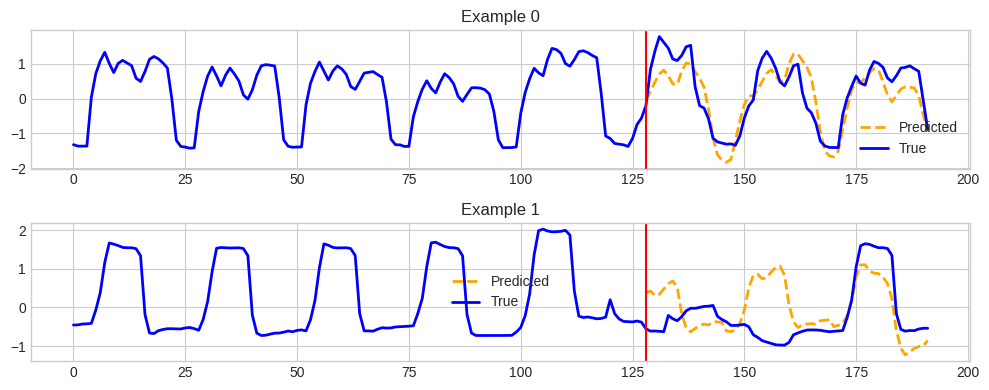

In [11]:
if freeze_backbone:
    print(
        "Number of params before freezing backbone",
        count_parameters(finetune_forecast_model),
    )

    # Freeze the backbone of the model
    for param in finetune_forecast_model.backbone.parameters():
        param.requires_grad = False

    # Count params
    print(
        "Number of params after freezing the backbone",
        count_parameters(finetune_forecast_model),
    )

# Find optimal learning rate
# Use with caution: Set it manually if the suggested learning rate is not suitable
if learning_rate is None:
    learning_rate, finetune_forecast_model = optimal_lr_finder(
        finetune_forecast_model,
        dset_train,
        batch_size=train_batch_size,
    )
    print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

print(f"Using learning rate = {learning_rate}")
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(out_dir, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    dataloader_num_workers=8,
    report_to="none",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(out_dir, "logs"),  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
    seed=SEED,
)

# Create the early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=1e-5,  # Minimum improvement required to consider as improvement
)
tracking_callback = TrackingCallback()

# Optimizer and scheduler
optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(dset_train) / (train_batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=dset_train,
    eval_dataset=dset_val,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)
finetune_forecast_trainer.remove_callback(INTEGRATION_TO_CALLBACK["codecarbon"])

# Fine tune
finetune_forecast_trainer.train()

# Evaluation
print("+" * 20, f"Test MSE after few-shot {fewshot_percent}% fine-tuning", "+" * 20)

finetune_forecast_trainer.model.loss = "mse"  # fixing metric to mse for evaluation

fewshot_output = finetune_forecast_trainer.evaluate(dset_test)
print(fewshot_output)
print("+" * 60)

# get predictions

predictions_dict = finetune_forecast_trainer.predict(dset_test)

predictions_np = predictions_dict.predictions[0]

print(predictions_np.shape)

# get backbone embeddings (if needed for further analysis)

backbone_embedding = predictions_dict.predictions[1]

print(backbone_embedding.shape)

# plot
plot_predictions(
    model=finetune_forecast_trainer.model,
    dset=dset_test,
    plot_dir=os.path.join(OUT_DIR, dataset_name),
    plot_prefix="test_fewshot",
    indices=[0, 1],
    channel=0,
)